# Diabetes Readmission - distribuciones de variables

Carga el dataset `diabetes_readmission` de TableShift con el mismo patron de `test.ipynb` y define funciones para visualizar distribuciones numericas y categoricas.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tableshift import get_dataset
from tableshift.core.features import PreprocessorConfig

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
def find_project_root(start=Path.cwd()):
    """Return the repository root that contains pyproject.toml and data/."""
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "data").exists():
            return path
    raise RuntimeError("No se encontro la raiz del repo")


PROJECT_ROOT = find_project_root()
CACHE_DIR = PROJECT_ROOT / "data" / "raw" / "tableshift_cache"

print(f"Project root: {PROJECT_ROOT}" f"\nCache dir: {CACHE_DIR}")

Project root: c:\Users\jeffr\GitHub\tesis-darl
Cache dir: c:\Users\jeffr\GitHub\tesis-darl\data\raw\tableshift_cache


In [3]:
def passthrough_preprocessor() -> PreprocessorConfig:
    """Return a PreprocessorConfig that skips TableShift transformations."""
    return PreprocessorConfig(
        categorical_features="passthrough",
        numeric_features="passthrough",
        dropna="all",
    )

In [4]:
DATASET_NAME = "diabetes_readmission"

dset = get_dataset(
    DATASET_NAME,
    cache_dir=str(CACHE_DIR),
    preprocessor_config=passthrough_preprocessor(),
)

print(dset)

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(


TabularDataset(name='diabetes_readmission', preprocessor_config=PreprocessorConfig(categorical_features='passthrough', numeric_features='passthrough', domain_labels='label_encode', passthrough_columns=None, dropna='all', use_extended_names=False, map_targets=False, cast_targets_to_default_type=False, min_frequency=None, max_categories=None, n_bins=5, sub_illegal_chars=True), config=DatasetConfig(cache_dir='c:\\Users\\jeffr\\GitHub\\tesis-darl\\data\\raw\\tableshift_cache', download=True, random_seed=948324), initialize_data=True, splitter=DomainSplitter(val_size=0.1, random_state=264738, id_test_size=0.1, domain_split_varname='admission_source_id', domain_split_ood_values=[7], domain_split_id_values=None, domain_split_gt_thresh=None, drop_domain_split_col=True, ood_val_size=0.1), grouper=Grouper(features_and_values={'race': ['Caucasian'], 'gender': ['Male']}, drop=False, transformer=None), feature_names=['acarbose', 'max_glu_serum', 'medical_specialty', 'num_medications', 'number_emerg

In [5]:
X_train, y_train, g_train, _ = dset.get_pandas(split="train")
X_val, y_val, g_val, _ = dset.get_pandas(split="validation")
X_id_test, y_id_test, g_id_test, _ = dset.get_pandas(split="id_test")
X_ood, y_ood, g_ood, _ = dset.get_pandas(split="ood_test")

splits = {
    "train": (X_train, y_train),
    "validation": (X_val, y_val),
    "id_test": (X_id_test, y_id_test),
    "ood_test": (X_ood, y_ood),
}

for split_name, (X_split, y_split) in splits.items():
    print(f"{split_name:10s} X={X_split.shape} y={y_split.shape}")

train      X=(34288, 46) y=(34288,)
validation X=(4286, 46) y=(4286,)
id_test    X=(4287, 46) y=(4287,)
ood_test   X=(50968, 46) y=(50968,)


In [13]:
def split_feature_types(df: pd.DataFrame, cardinality_threshold: int = 20):
    """Separate continuous numeric, ordinal numeric, and categorical columns."""
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    continuous_cols = [
        col
        for col in numeric_cols
        if df[col].nunique(dropna=True) > cardinality_threshold
    ]
    ordinal_cols = [
        col
        for col in numeric_cols
        if df[col].nunique(dropna=True) <= cardinality_threshold
    ]

    return continuous_cols, ordinal_cols, categorical_cols


continuous_cols, ordinal_cols, categorical_cols = split_feature_types(X_train)

print(f"Continuas numericas ({len(continuous_cols)}):")

for col in continuous_cols:
    print(f"  - {col}")

print(f"Ordinales numericas ({len(ordinal_cols)}):")
for col in ordinal_cols:
    print(f"  - {col}")

print(f"Categoricas ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Continuas numericas (4):
  - discharge_disposition_id
  - num_lab_procedures
  - num_medications
  - number_outpatient
Ordinales numericas (8):
  - race
  - gender
  - admission_type_id
  - time_in_hospital
  - num_procedures
  - number_emergency
  - number_inpatient
  - number_diagnoses
Categoricas (34):
  - age
  - weight
  - payer_code
  - medical_specialty
  - diag_1
  - diag_2
  - diag_3
  - max_glu_serum
  - A1Cresult
  - metformin
  - repaglinide
  - nateglinide
  - chlorpropamide
  - glimepiride
  - acetohexamide
  - glipizide
  - glyburide
  - tolbutamide
  - pioglitazone
  - rosiglitazone
  - acarbose
  - miglitol
  - troglitazone
  - tolazamide
  - examide
  - citoglipton
  - insulin
  - glyburide-metformin
  - glipizide-metformin
  - glimepiride-pioglitazone
  - metformin-rosiglitazone
  - metformin-pioglitazone
  - change
  - diabetesMed


In [7]:
def plot_numeric_distributions(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    bins: int = 30,
    max_cols: int = 3,
    figsize_per_plot: tuple[float, float] = (4.5, 3.0),
):
    """Plot histograms for numeric variables in a DataFrame."""
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    columns = [col for col in columns if col in df.columns]
    if not columns:
        raise ValueError("No hay columnas numericas para plotear")

    n_cols = min(max_cols, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
    )

    for ax, col in zip(axes.ravel(), columns):
        values = df[col].dropna()
        ax.hist(values, bins=bins, color="#3b82f6", edgecolor="white", alpha=0.85)
        ax.set_title(col)
        ax.set_ylabel("Frecuencia")
        ax.grid(axis="y", alpha=0.25)

    for ax in axes.ravel()[len(columns) :]:
        ax.set_visible(False)

    fig.tight_layout()
    return fig, axes

In [8]:
def plot_categorical_distributions(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    top_n: int = 15,
    max_cols: int = 2,
    figsize_per_plot: tuple[float, float] = (6.0, 3.5),
):
    """Plot bar charts for categorical or low-cardinality variables."""
    if columns is None:
        columns = df.select_dtypes(
            include=["object", "category", "bool"]
        ).columns.tolist()

    columns = [col for col in columns if col in df.columns]
    if not columns:
        raise ValueError("No hay columnas categoricas para plotear")

    n_cols = min(max_cols, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
    )

    for ax, col in zip(axes.ravel(), columns):
        counts = df[col].astype("string").fillna("<NA>").value_counts().head(top_n)
        ax.barh(counts.index[::-1], counts.values[::-1], color="#10b981", alpha=0.9)
        ax.set_title(col)
        ax.set_xlabel("Frecuencia")
        ax.grid(axis="x", alpha=0.25)

    for ax in axes.ravel()[len(columns) :]:
        ax.set_visible(False)

    fig.tight_layout()
    return fig, axes

In [9]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numeric_cols: list[str] | None = None,
    categorical_cols: list[str] | None = None,
    ordinal_as_categorical: bool = True,
    cardinality_threshold: int = 20,
):
    """Plot numeric and categorical distributions for a TableShift split."""
    continuous, ordinal, inferred_categorical = split_feature_types(
        df,
        cardinality_threshold=cardinality_threshold,
    )

    if numeric_cols is None:
        numeric_cols = continuous if ordinal_as_categorical else continuous + ordinal
    if categorical_cols is None:
        categorical_cols = inferred_categorical + (
            ordinal if ordinal_as_categorical else []
        )

    figures = {}
    if numeric_cols:
        figures["numeric"] = plot_numeric_distributions(df, numeric_cols)
    if categorical_cols:
        figures["categorical"] = plot_categorical_distributions(df, categorical_cols)

    return figures

## Ejemplos de uso

Ejecuta las celdas siguientes para visualizar el split de entrenamiento. Ajusta `top_n`, `bins` o las listas de columnas si quieres revisar subconjuntos concretos.


(<Figure size 1350x600 with 6 Axes>,
 array([[<Axes: title={'center': 'discharge_disposition_id'}, ylabel='Frecuencia'>,
         <Axes: title={'center': 'num_lab_procedures'}, ylabel='Frecuencia'>,
         <Axes: title={'center': 'num_medications'}, ylabel='Frecuencia'>],
        [<Axes: title={'center': 'number_outpatient'}, ylabel='Frecuencia'>,
         <Axes: >, <Axes: >]], dtype=object))

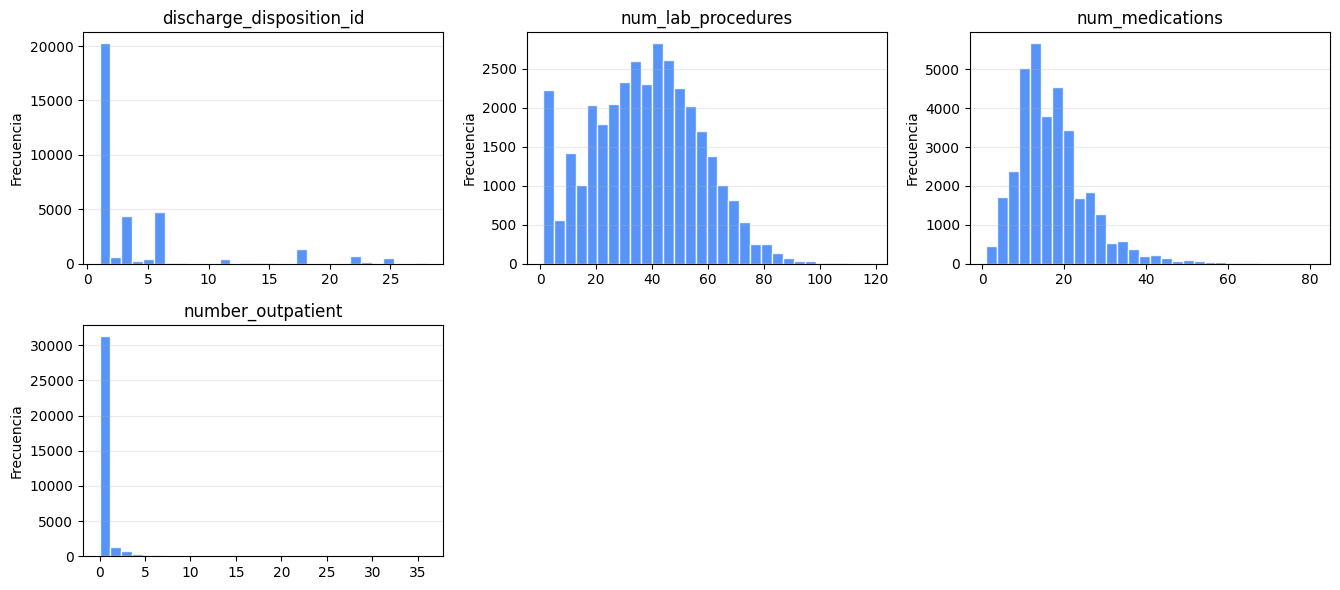

In [10]:
plot_numeric_distributions(X_train, continuous_cols, bins=30)

In [ ]:
plot_categorical_distributions(X_train, categorical_cols + ordinal_cols, top_n=15)

In [ ]:
# Funcion combinada para cualquier split cargado:
# figures = plot_feature_distributions(X_ood)

## Variables clinicas y administrativas destacadas

Esta seccion concentra las variables mas utiles para interpretar riesgo de readmision y posibles cambios de distribucion: estancia hospitalaria, intensidad de atencion, historial de uso del sistema, diagnosticos, HbA1c, medicacion, demografia y contexto de admision/alta.


In [ ]:
SIGNIFICANT_NUMERIC_VARIABLES = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

SIGNIFICANT_CATEGORICAL_VARIABLES = [
    "readmitted",
    "A1Cresult",
    "diag_1",
    "diag_2",
    "diag_3",
    "admission_type_id",
    "admission_source_id",
    "discharge_disposition_id",
    "age",
    "gender",
    "race",
    "change",
    "diabetesMed",
    "insulin",
    "metformin",
]


def available_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    """Return requested columns that are present in the DataFrame."""
    return [column for column in columns if column in df.columns]


def missing_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    """Return requested columns that are not present in the DataFrame."""
    return [column for column in columns if column not in df.columns]


significant_numeric_cols = available_columns(X_train, SIGNIFICANT_NUMERIC_VARIABLES)
significant_categorical_cols = available_columns(
    X_train, SIGNIFICANT_CATEGORICAL_VARIABLES
)

print(
    f"Numericas disponibles ({len(significant_numeric_cols)}): {significant_numeric_cols}"
)
print(
    f"Categoricas disponibles ({len(significant_categorical_cols)}): {significant_categorical_cols}"
)

missing_significant_cols = missing_columns(
    X_train,
    SIGNIFICANT_NUMERIC_VARIABLES + SIGNIFICANT_CATEGORICAL_VARIABLES,
)
if missing_significant_cols:
    print(
        f"No disponibles en X_train ({len(missing_significant_cols)}): {missing_significant_cols}"
    )

Numericas disponibles (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categoricas disponibles (13): ['A1Cresult', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'age', 'gender', 'race', 'change', 'diabetesMed', 'insulin', 'metformin']
No disponibles en X_train (2): ['readmitted', 'admission_source_id']


In [15]:
def plot_frequency_table(
    series: pd.Series,
    title: str,
    top_n: int = 15,
    ax=None,
):
    """Plot absolute and relative frequency for a single variable."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    counts = series.astype("string").fillna("<NA>").value_counts().head(top_n)
    percentages = counts / counts.sum() * 100

    ax.barh(counts.index[::-1], counts.values[::-1], color="#0f766e", alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Frecuencia")
    ax.grid(axis="x", alpha=0.25)

    for patch, pct in zip(ax.patches, percentages[::-1]):
        ax.text(
            patch.get_width(),
            patch.get_y() + patch.get_height() / 2,
            f" {pct:.1f}%",
            va="center",
            fontsize=9,
        )

    return ax

In [16]:
def plot_significant_variable_distributions(
    df: pd.DataFrame,
    y: pd.Series | None = None,
    numeric_cols: list[str] | None = None,
    categorical_cols: list[str] | None = None,
    bins: int = 30,
    top_n: int = 15,
):
    """Plot distributions and frequencies for selected clinical variables."""
    numeric_cols = available_columns(
        df,
        numeric_cols or SIGNIFICANT_NUMERIC_VARIABLES,
    )
    categorical_cols = available_columns(
        df,
        categorical_cols or SIGNIFICANT_CATEGORICAL_VARIABLES,
    )

    if y is not None and "readmitted" in SIGNIFICANT_CATEGORICAL_VARIABLES:
        y_name = y.name or "readmitted"
        df = df.copy()
        df[y_name] = y
        if y_name not in categorical_cols:
            categorical_cols = [y_name, *categorical_cols]

    figures = {}
    if numeric_cols:
        figures["numeric"] = plot_numeric_distributions(
            df,
            numeric_cols,
            bins=bins,
            max_cols=2,
            figsize_per_plot=(5.5, 3.2),
        )
    if categorical_cols:
        figures["categorical"] = plot_categorical_distributions(
            df,
            categorical_cols,
            top_n=top_n,
            max_cols=2,
            figsize_per_plot=(6.2, 3.8),
        )

    return figures

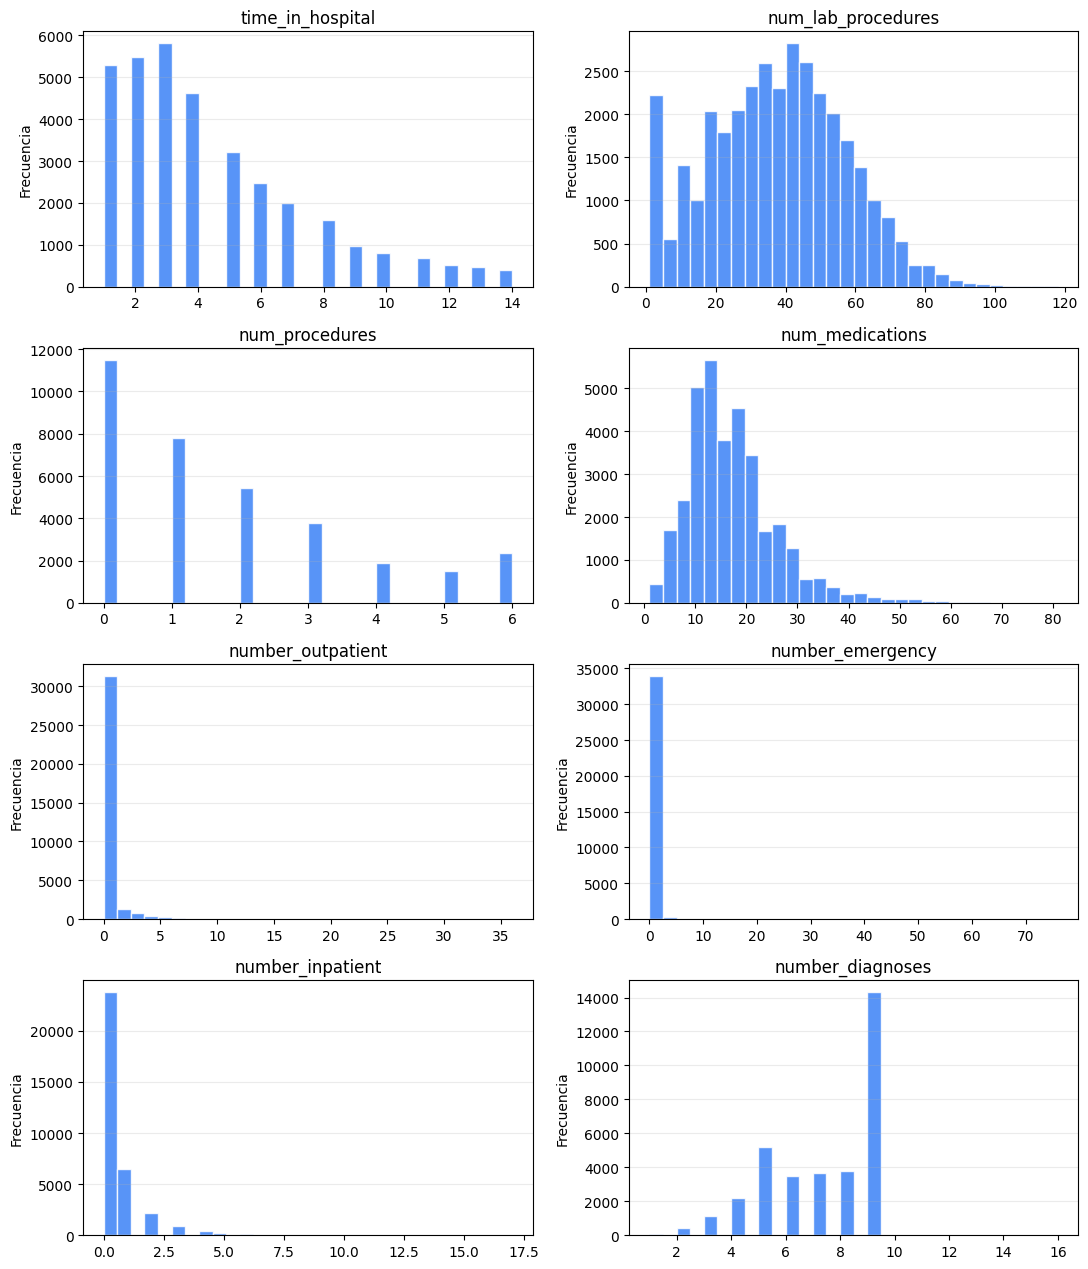

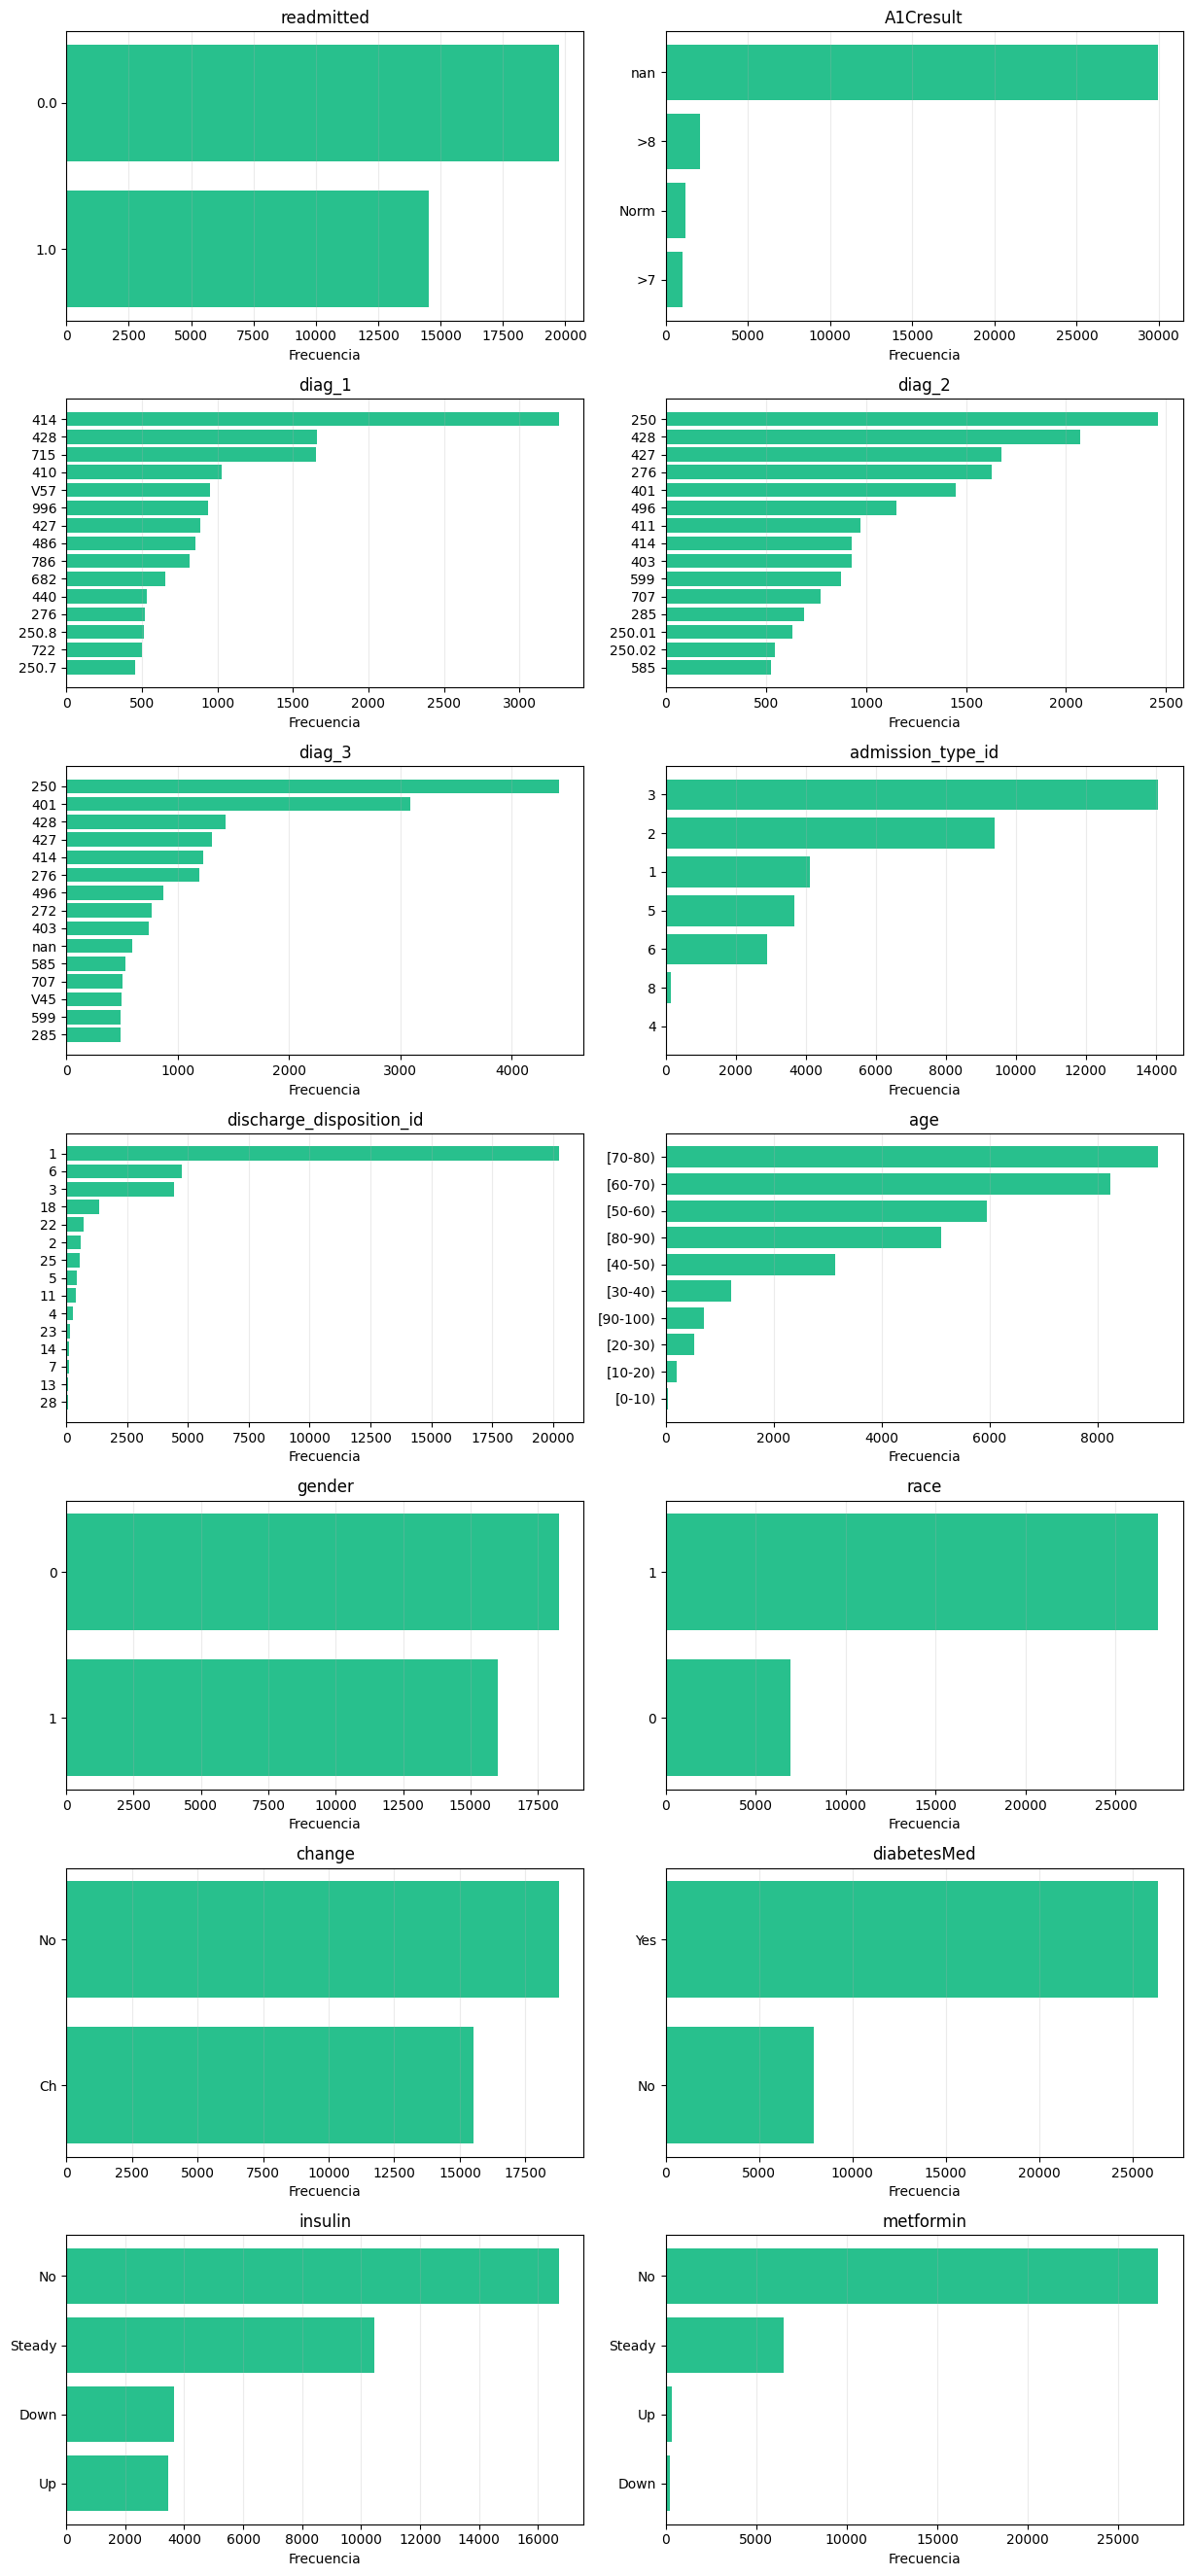

In [ ]:
plot_significant_variable_distributions(
    X_train,
    y=y_train,
    bins=30,
    top_n=15,
)

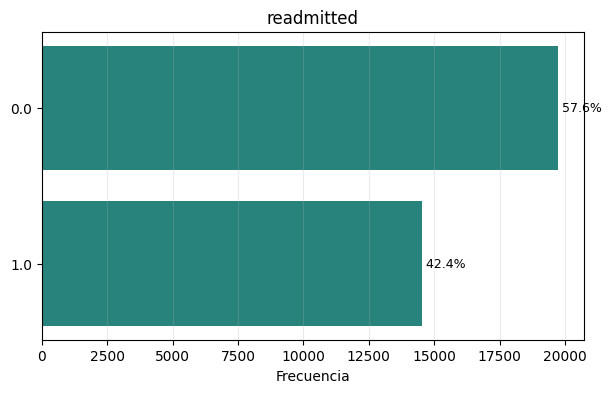

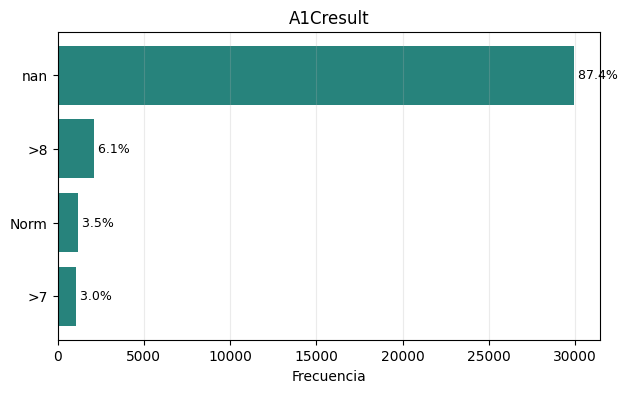

In [ ]:
# Frecuencia detallada de una variable especifica:
plot_frequency_table(y_train, title="readmitted", top_n=3)
plot_frequency_table(X_train["A1Cresult"], title="A1Cresult", top_n=10)